In [1]:
from util.utils import get_som_labeled_img, check_ocr_box, get_caption_model_processor, get_yolo_model
import torch
from ultralytics import YOLO
from PIL import Image
device = 'mps'
model_path='weights/icon_detect/model.pt'

som_model = get_yolo_model(model_path)

som_model.to(device)
print('model to {}'.format(device))


model to mps


In [2]:
# two choices for caption model: fine-tuned blip2 or florence2
import importlib
# import util.utils
# importlib.reload(utils)
from util.utils import get_som_labeled_img, check_ocr_box, get_caption_model_processor, get_yolo_model

caption_model_processor = get_caption_model_processor(model_name="florence2", model_name_or_path="weights/icon_caption_florence", device=device)



Florence2LanguageForConditionalGeneration has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


In [3]:
som_model.device, type(som_model) 

(device(type='mps', index=0), ultralytics.models.yolo.model.YOLO)

In [3]:
# reload utils
import importlib
import util.utils as utils
importlib.reload(utils)
# from utils import get_som_labeled_img, check_ocr_box, get_caption_model_processor, get_yolo_model

image_path = 'imgs/google_page.png'
image_path = 'imgs/windows_home.png'
image_path = 'imgs/mac_home.png'
image_path = 'imgs/mac_home_vs.png'

# image_path = 'imgs/windows_multitab.png'
# image_path = 'imgs/omni3.jpg'
# image_path = 'imgs/ios.png'
# image_path = 'imgs/word.png'
# image_path = 'imgs/excel2.png'

image = Image.open(image_path)
image_rgb = image.convert('RGB')
print('image size:', image.size)

box_overlay_ratio = max(image.size) / 3200
draw_bbox_config = {
    'text_scale': 0.8 * box_overlay_ratio,
    'text_thickness': max(int(2 * box_overlay_ratio), 1),
    'text_padding': max(int(3 * box_overlay_ratio), 1),
    'thickness': max(int(3 * box_overlay_ratio), 1),
}
BOX_TRESHOLD = 0.05

import time
start = time.time()
ocr_bbox_rslt, is_goal_filtered = check_ocr_box(image_path, display_img = False, output_bb_format='xyxy', goal_filtering=None, easyocr_args={'paragraph': False, 'text_threshold':0.9}, use_paddleocr=True)
text, ocr_bbox = ocr_bbox_rslt
cur_time_ocr = time.time() 

dino_labled_img, label_coordinates, parsed_content_list = get_som_labeled_img(image_path, som_model, BOX_TRESHOLD = BOX_TRESHOLD, output_coord_in_ratio=True, ocr_bbox=ocr_bbox,draw_bbox_config=draw_bbox_config, caption_model_processor=caption_model_processor, ocr_text=text,use_local_semantics=True, iou_threshold=0.7, scale_img=False, batch_size=128)
cur_time_caption = time.time() 


image size: (3456, 2234)

0: 832x1280 75 icons, 168.9ms
Speed: 10.2ms preprocess, 168.9ms inference, 65.9ms postprocess per image at shape (1, 3, 832, 1280)
len(filtered_boxes): 81 22
time to get parsed content: 8.501065969467163


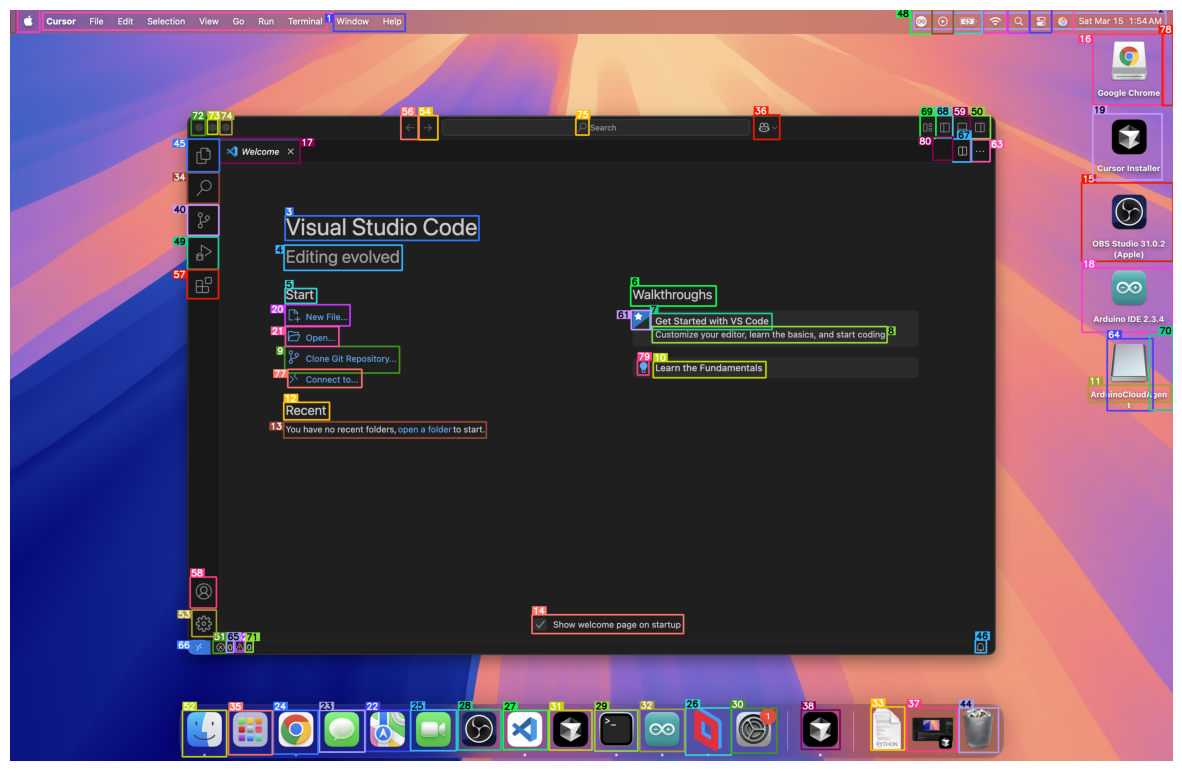

In [4]:
# plot dino_labled_img it is in base64
import base64
import matplotlib.pyplot as plt
import io
plt.figure(figsize=(15,15))

image = Image.open(io.BytesIO(base64.b64decode(dino_labled_img)))
plt.axis('off')

plt.imshow(image)
# print(len(parsed_content_list))


In [5]:
import pandas as pd
df = pd.DataFrame(parsed_content_list)
df['ID'] = range(len(df))

df

,type,bbox,interactivity,content,source,ID
0,text,"[0.028067128732800484, 0.0049239033833146095, ...",False,Cursor File Edit Selection View Go Run Terminal,box_ocr_content_ocr,0
1,text,"[0.27806714177131653, 0.006714413408190012, 0....",False,WindowHelp,box_ocr_content_ocr,1
2,text,"[0.7769097089767456, 0.0049239033833146095, 0....",False,8 O C Q SatMar15 1:54AM,box_ocr_content_ocr,2
3,text,"[0.23640047013759613, 0.27484333515167236, 0.4...",False,Visual Studio Code,box_ocr_content_ocr,3
4,text,"[0.23582175374031067, 0.31378692388534546, 0.3...",False,Editing evolved,box_ocr_content_ocr,4
...,...,...,...,...,...,...
76,icon,"[2.5432185793761164e-05, 0.0, 0.00500234914943...",True,a blank space or screen.,box_yolo_content_yolo,76
77,icon,"[0.23876997828483582, 0.47905877232551575, 0.3...",True,A text message or message editor.,box_yolo_content_yolo,77
78,icon,"[0.9908137917518616, 0.03247250244021416, 1.0,...",True,a purple rectangle.,box_yolo_content_yolo,78
79,icon,"[0.5395587682723999, 0.4675869941711426, 0.549...",True,a chat or messaging function.,box_yolo_content_yolo,79


In [15]:
parsed_content_list

[{'type': 'text',
  'bbox': [0.1500781625509262,
   0.011121409013867378,
   0.3272537887096405,
   0.03521779552102089],
  'interactivity': False,
  'content': 'Document 10.docx  General*  Last Modified: Just now ',
  'source': 'box_ocr_content_ocr'},
 {'type': 'text',
  'bbox': [0.034392911940813065,
   0.04726598784327507,
   0.05523710325360298,
   0.07228915393352509],
  'interactivity': False,
  'content': 'Home',
  'source': 'box_ocr_content_ocr'},
 {'type': 'text',
  'bbox': [0.22094841301441193,
   0.048192769289016724,
   0.2542991042137146,
   0.07321593910455704],
  'interactivity': False,
  'content': 'Mailings',
  'source': 'box_ocr_content_ocr'},
 {'type': 'text',
  'bbox': [0.2595101594924927,
   0.05004633963108063,
   0.2845231890678406,
   0.07136237621307373],
  'interactivity': False,
  'content': 'Review',
  'source': 'box_ocr_content_ocr'},
 {'type': 'text',
  'bbox': [0.31474727392196655,
   0.05004633963108063,
   0.3335070312023163,
   0.07136237621307373],
  